**Analysis of Evaluation Dataset Paragraph Sizes for Chunking**

In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from config import CACHE_DIR
from utils import save_fig

def plot_sizes(chunk_sizes: list[int], title: str, save: bool, annotation: str = None, elbow: int = 500) -> None:
    median = np.median(chunk_sizes)
    min_val = min(chunk_sizes)
    max_val = max(chunk_sizes)
    
    # Count papers after the elbow
    after_elbow = sum(1 for s in chunk_sizes if s > elbow)
    after_elbow_pct = (after_elbow / len(chunk_sizes)) * 100

    plt.plot(chunk_sizes)
    plt.title(label=title, loc='center')

    # Median line
    plt.axhline(y=median, color='red', linestyle='--', label=f'Median: {median:.1f}')
    # Min/max lines
    plt.axhline(y=min_val, color='green', linestyle=':', label=f'Min: {min_val}')
    plt.axhline(y=max_val, color='orange', linestyle=':', label=f'Max: {max_val}')
    # Elbow line
    plt.axhline(y=elbow, color='purple', linestyle='-.', label=f'Elbow ({elbow}): {after_elbow} chunks ({after_elbow_pct:.1f}%)')

    plt.legend()
    plt.ylabel("# Tokens")

    if annotation:
        plt.figtext(0.5, -0.02, "Note: " + annotation, ha="center", fontsize=9, color="gray")
    if save:
        save_fig(title)

(1133 tokens) [6fcf2285-7d7a-1014-8317-cc5e3b51bff2.json]: TCCGGACTCAGATCTCGAGCTCAAGCTTCGatggactcagtacctgccactgtgccttctatcgccgctaccccgggggacccggaacttgtgggacccttgtctgtgctctacgcagccttcatagccaagctgctggagctagttgctacattgcctgatgatgttcagcctgggcctgatttttatggactgccatggaaacctgtatttatcactgccttcttgggaattgcttcgtttgccattttcttatggagaactgtccttgttgtgaaggatagagtatatcaagtcacggaacagcaaatttctgagaagttgaagactatcatgaaagaaaatacagaacttgtacaaaaattgtcaaattatgaacagaagatcaaggaatcaaagaaacatgttcaggaaaccaggaaacaaaatatgattctctctgatgaagcaattaaatataaggataaaatcaagacacttgaaaaaaatcaggaaattctggatgacacagctaaaaatcttcgtgttatgctagaatctgagagagaacagaatgtcaagaatcaggacttgatatcagaaaacaagaaatctatagagaagttaaaggatgttatttcaatgaatgcctcagaattttcagaggttcagattgcacttaatgaagctaagcttagtgaagagaaggtgaagtctgaatgccatcgggttcaagaagaaaatgctaggcttaagaagaaaaaagagcagttgcagcaggaaatcgaagactggagtaaattacatgctgagctcagtgagcaaatcaaatcatttgagaagtctcagaaagatttggaagtagctcttactcacaaggatgataatattaatgctttgactaactgcattacacagttgaatctgttagagtgtgaatctgaatctgagggtcaaaataa

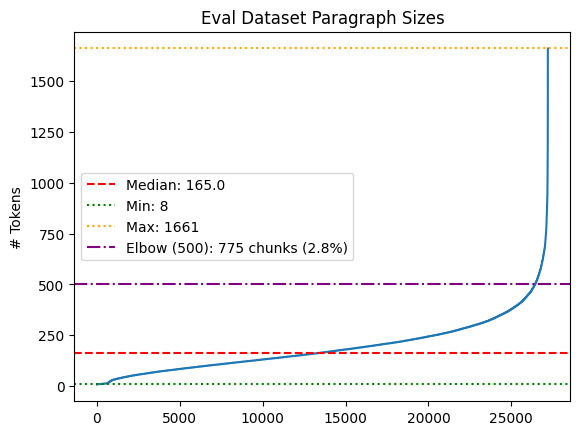

In [12]:
DIR = CACHE_DIR

chunk_sizes: list[int] = []
all_chunks: list[tuple[str, dict]] = []

for paper in DIR.iterdir():
    with open(paper, "r") as f:
        data = json.load(f)
    for chunk in data['abstract'] + data['body']:
        chunk_sizes.append(chunk['n_tokens'])
        all_chunks.append((paper.name, chunk))

chunk_sizes.sort()

min_chunks = sorted(all_chunks, key=lambda x: x[1]['n_tokens'])[-10:]

for paper, chunk in min_chunks:
    print(f"({chunk['n_tokens']} tokens) [{paper}]: {chunk['text']}")

plot_sizes(chunk_sizes,
                 title="Eval Dataset Paragraph Sizes",
                 save=False)